In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split


In [3]:
#Load LSTM data
PROCESSED_DIR = Path("/content/drive/MyDrive/data/processed")

data = np.load(PROCESSED_DIR / "auslan_lstm_processed.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("Files: ",data.files)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Files:  ['X_train', 'y_train', 'X_test', 'y_test']
X_train: (1710, 57, 22)
X_test : (855, 57, 22)
y_train: (1710,)
y_test : (855,)


In [4]:
#Build 1 Layer Architecture LSTM
"""Use a fixed random seed to make LSTM experiments reproducible, so that differences
in performance between architectures are less likely to be caused by random initialization
or data shuffling, allowing for a more reliable comparison."""

"""
Evaluate 3 LSTM architectures on validation set, choose best model and evaluate on test set.
"""

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

tf.keras.utils.set_random_seed(SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(128),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(95, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 95)             │        12,255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,567 (349.87 KB)

 Trainable params: 89,567 (349.87 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train LSTM model
#Reserve 10% of training data for validation

#Explicit stratified validation split
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
history = model.fit(
    X_train_fit,
    y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.0409 - loss: 4.4194 - val_accuracy: 0.0994 - val_loss: 4.0339
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.1228 - loss: 3.6847 - val_accuracy: 0.1404 - val_loss: 3.3407
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.1923 - loss: 3.1256 - val_accuracy: 0.2222 - val_loss: 2.9745
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.2346 - loss: 2.7302 - val_accuracy: 0.2222 - val_loss: 2.7171
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.2865 - loss: 2.4992 - val_accuracy: 0.2398 - val_loss: 2.5117
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.2982 - loss: 2.3824 - val_accuracy: 0.3333 - val_loss: 2.4731
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.3489 - loss: 2.1471 - val_accuracy: 0.3099 - val_loss: 2.2932
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3717 - loss: 2.0498 - val_accuracy: 0.3509 - 

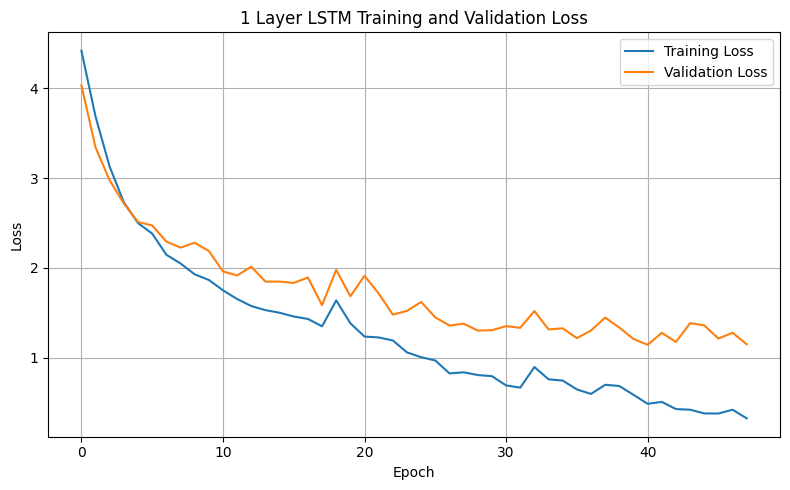

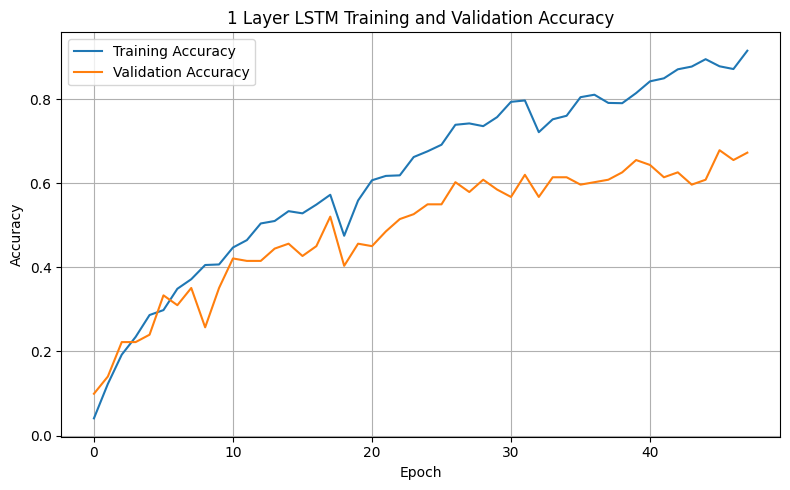

In [6]:
#Validation / Training Loss and Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1 Layer LSTM Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1 Layer LSTM Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
#Build 2 Layer Architecture LSTM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

tf.keras.utils.set_random_seed(SEED)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(95, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 57, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 57, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 95)             │         6,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,895 (519.12 KB)

 Trainable params: 132,895 (519.12 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model_2.fit(
    X_train_fit,
    y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
val_loss, val_accuracy = model_2.evaluate(
    X_val,
    y_val,
    verbose=0
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.0377 - loss: 4.4634 - val_accuracy: 0.0760 - val_loss: 4.2291
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.0877 - loss: 3.9647 - val_accuracy: 0.1813 - val_loss: 3.6829
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.1494 - loss: 3.4287 - val_accuracy: 0.1404 - val_loss: 3.2940
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.1722 - loss: 3.1593 - val_accuracy: 0.2105 - val_loss: 3.0099
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.2079 - loss: 2.9009 - val_accuracy: 0.2398 - val_loss: 2.8761
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.2625 - loss: 2.6638 - val_accuracy: 0.2164 - val_loss: 2.7752
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.2904 - loss: 2.5228 - val_accuracy: 0.3158 - val_loss: 2.5324
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.3262 - loss: 2.3351 - val_accuracy: 0.2982 

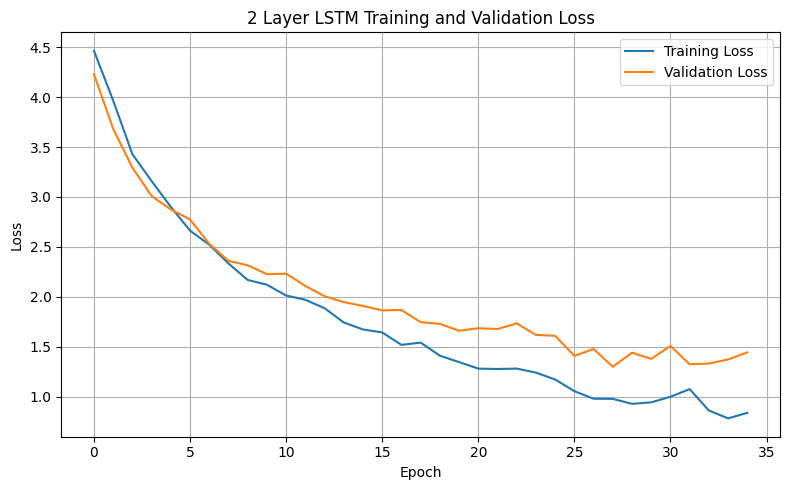

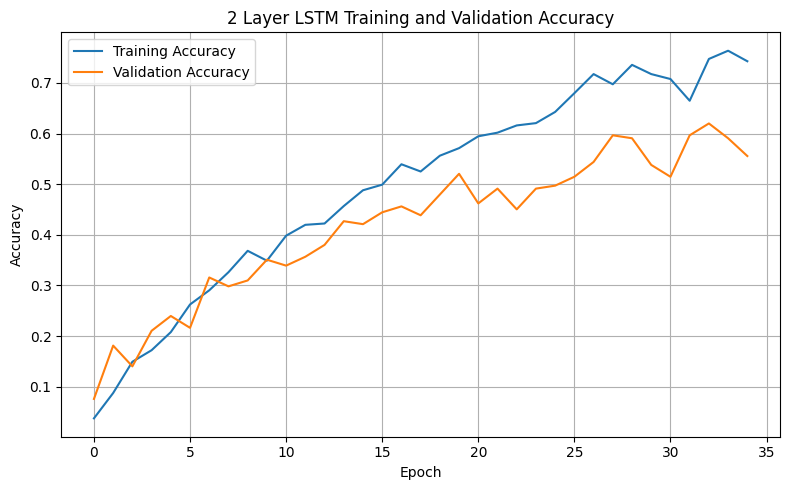

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2 Layer LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("2 Layer LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
#Build 3 Layer Architecture LSTM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

tf.keras.utils.set_random_seed(SEED)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(57, 22)),

    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(
        64,
        return_sequences=True
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(
        32
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        95,
        activation="softmax"
    )
])

model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 57, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 57, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 57, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 57, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 95)             │         3,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,271 (555.75 KB)

 Trainable params: 142,271 (555.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

In [12]:
history = model_3.fit(
    X_train_fit,
    y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
val_loss, val_accuracy = model_3.evaluate(
    X_val,
    y_val,
    verbose=0
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.0214 - loss: 4.4927 - val_accuracy: 0.0234 - val_loss: 4.3537
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.0546 - loss: 4.2307 - val_accuracy: 0.0702 - val_loss: 4.0623
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.0819 - loss: 3.9082 - val_accuracy: 0.0994 - val_loss: 3.7763
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.1137 - loss: 3.6520 - val_accuracy: 0.1696 - val_loss: 3.4825
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.1287 - loss: 3.4088 - val_accuracy: 0.1404 - val_loss: 3.2892
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.1494 - loss: 3.2631 - val_accuracy: 0.1988 - val_loss: 3.1036
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.1754 - loss: 3.1714 - val_accuracy: 0.2164 - val_loss: 3.0406
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.1819 - loss: 3.0333 - val_accuracy: 

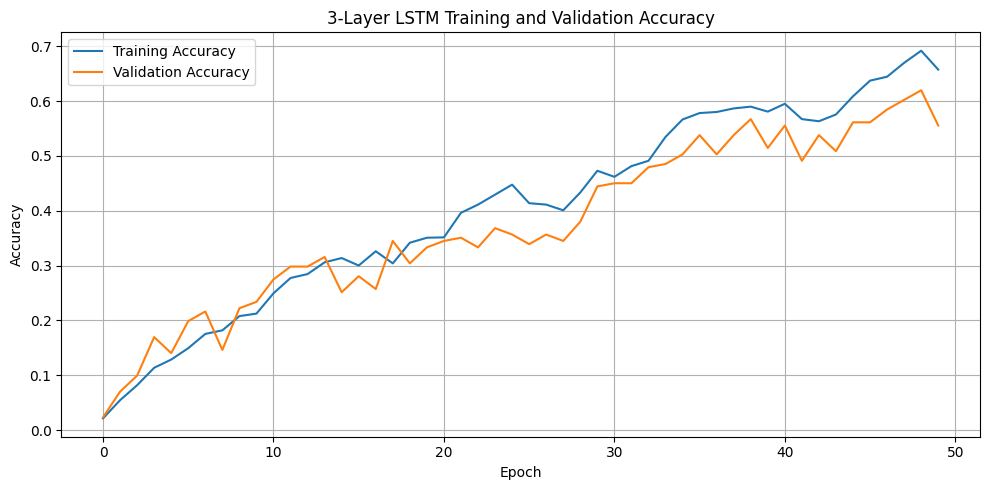

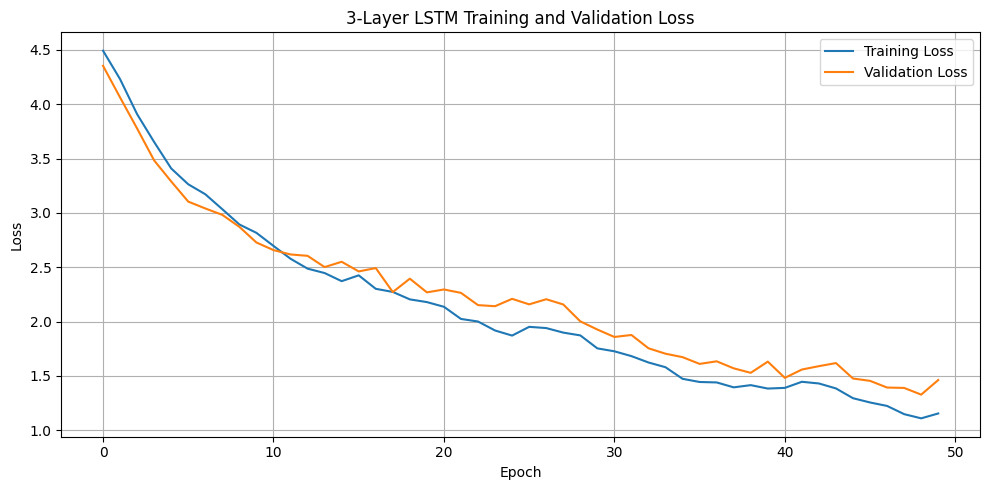

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("3-Layer LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3-Layer LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
label_mapping = pd.read_csv(PROCESSED_DIR / "label_mapping.csv")

target_names = (
    label_mapping
    .sort_values("class_id")["sign"]
    .tolist()
)

print(f"Number of sign classes: {len(target_names)}")

Number of sign classes: 95


In [16]:
#From validation tests, 1 layer LSTM has highest validation set accuracy and lowest validation loss, so we select that for further evaluation
# Final test evaluation: 1-layer LSTM

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(target_names)),
    target_names=target_names,
    digits=4,
    zero_division=0
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6433 - loss: 1.1390
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Test Loss: 1.1390
Test Accuracy: 0.6433
                precision    recall  f1-score   support

           God     0.5333    0.8889    0.6667         9
             I     0.5556    0.5556    0.5556         9
        Norway     0.7143    0.5556    0.6250         9
         alive     0.5714    0.4444    0.5000         9
           all     0.5000    0.5556    0.5263         9
        answer     0.6154    0.8889    0.7273         9
           boy     0.2500    0.1111    0.1538         9
      building     0.7143    0.5556    0.6250         9
           buy     0.9000    1.0000    0.9474         9
  change_mind_     0.6364    0.7778    0.7000         9
          cold     0.8182    1.0000    0.9000         9
          come     0.5556    0.5556    0.5556         9
  computer_PC_     1.0000    0.8889    0.9412         9
          cost     0.7273    0.8889    0.8000         9
     

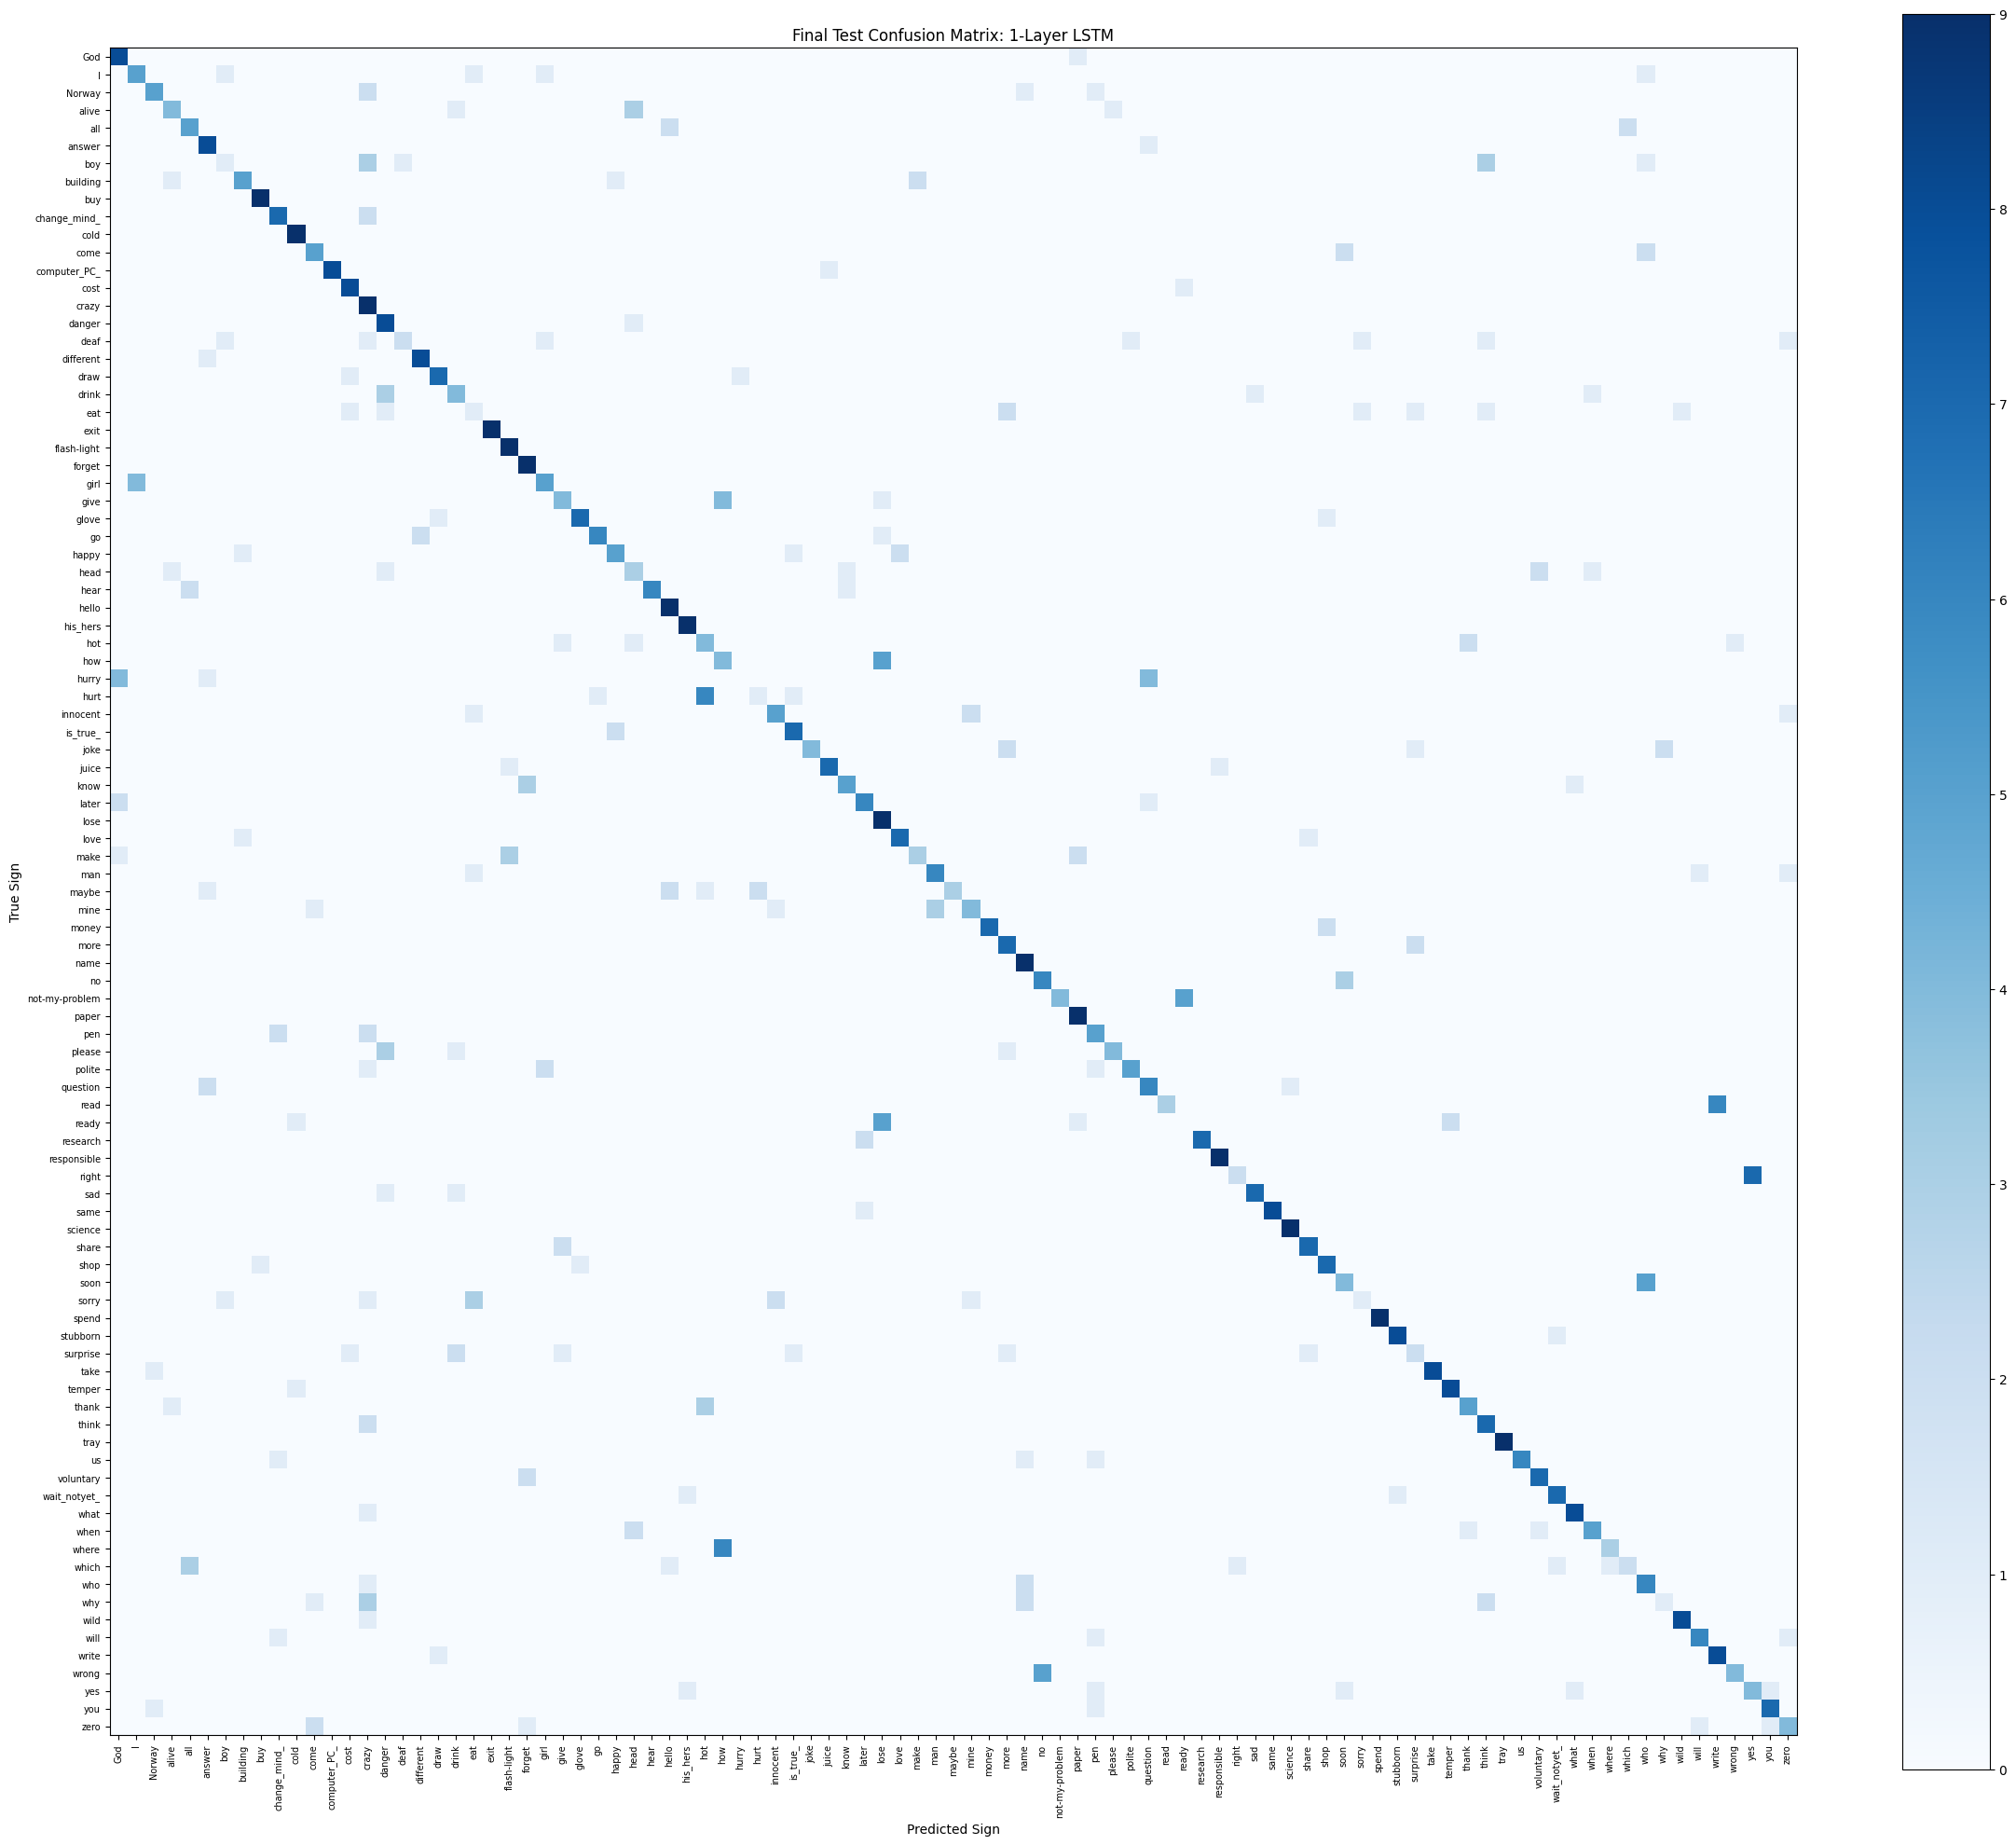

In [17]:
#Generate final confusion matrix for 1 layer LSTM

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(target_names))
)

plt.figure(figsize=(24, 20))
plt.imshow(cm, cmap="Blues")

plt.xlabel("Predicted Sign")
plt.ylabel("True Sign")
plt.title("Final Test Confusion Matrix: 1-Layer LSTM")

plt.xticks(
    range(len(target_names)),
    target_names,
    rotation=90,
    fontsize=7
)
plt.yticks(
    range(len(target_names)),
    target_names,
    fontsize=7
)

plt.colorbar()
plt.tight_layout()
plt.show()